In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

df = pd.read_csv("../data/processed/telco_cleaned.csv")

In [3]:
df["Churn_binary"] = df["Churn"].map({"No": 0, "Yes": 1})
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_binary
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


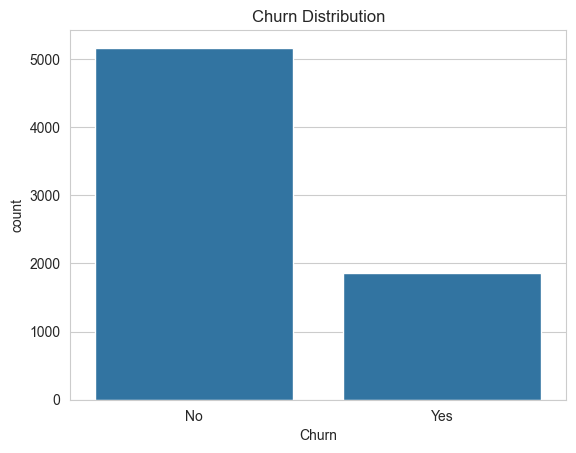

In [4]:
df["Churn"].value_counts()
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

In [5]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index")

Churn,No,Yes
Contract,,
Month-to-month,0.573579,0.426421
One year,0.887305,0.112695
Two year,0.971681,0.028319


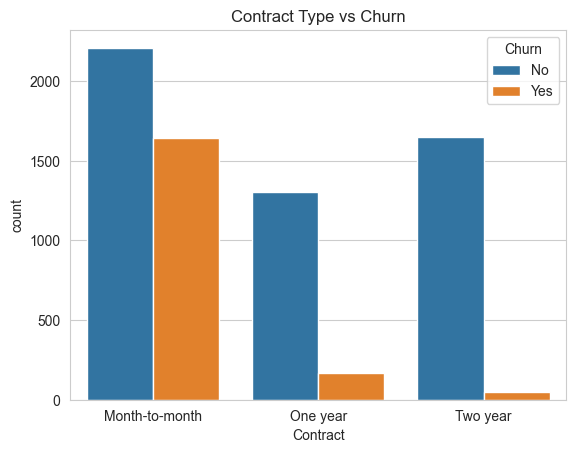

In [6]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract Type vs Churn")
plt.show()

In [7]:
pd.crosstab(df["InternetService"], df["Churn"], normalize="index")

Churn,No,Yes
InternetService,,
DSL,0.811079,0.188921
Fiber optic,0.582201,0.417799
No,0.927910,0.072090


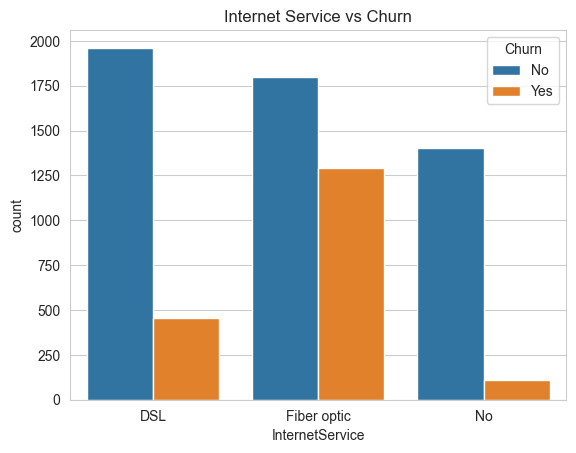

In [8]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Internet Service vs Churn")
plt.show()

In [9]:
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index")

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.548538,0.451462
Mailed check,0.810777,0.189223


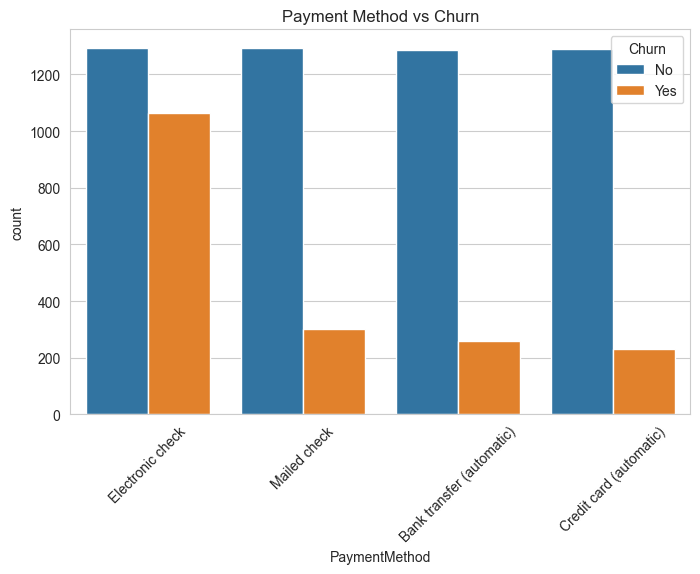

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")
plt.show()

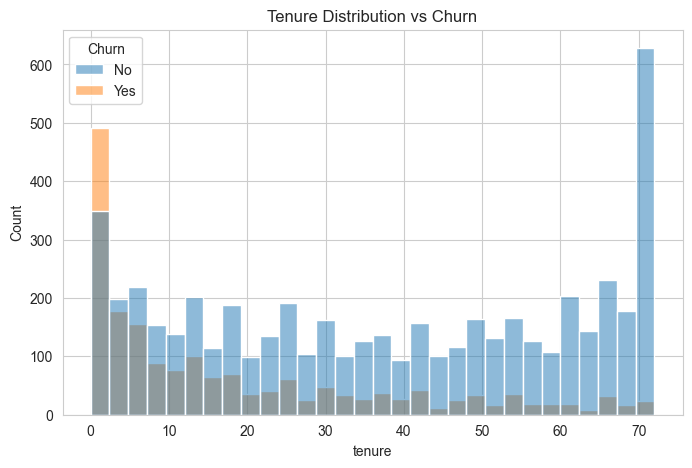

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30)
plt.title("Tenure Distribution vs Churn")
plt.show()

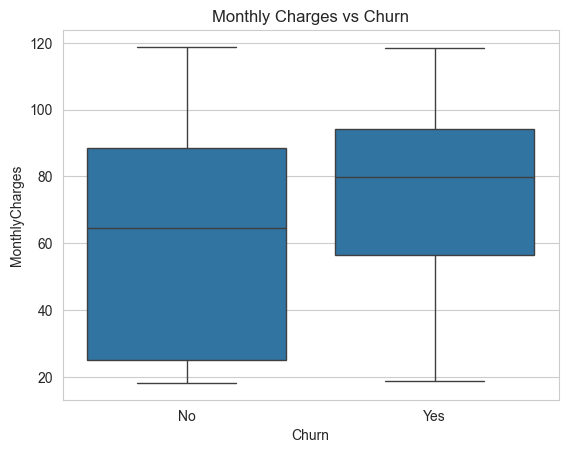

In [12]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

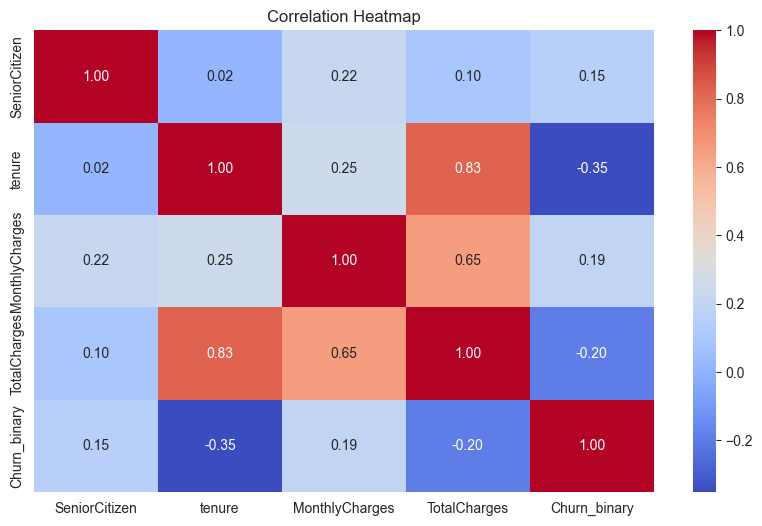

In [13]:
num_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [14]:
# Create tenure groups
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12", "12-24", "24-48", "48+"]
)

churn_table = pd.crosstab(
    [df["tenure_group"], df["Contract"]],
    df["Churn"],
    normalize="index"
)

churn_table

Churn                              No       Yes
tenure_group Contract                          
0-12         Month-to-month  0.486815  0.513185
             One year        0.894309  0.105691
             Two year        1.000000  0.000000
12-24        Month-to-month  0.622795  0.377205
             One year        0.918782  0.081218
             Two year        1.000000  0.000000
24-48        Month-to-month  0.670823  0.329177
             One year        0.893822  0.106178
             Two year        0.978102  0.021898
48+          Month-to-month  0.739766  0.260234
             One year        0.870662  0.129338
             Two year        0.966746  0.033254

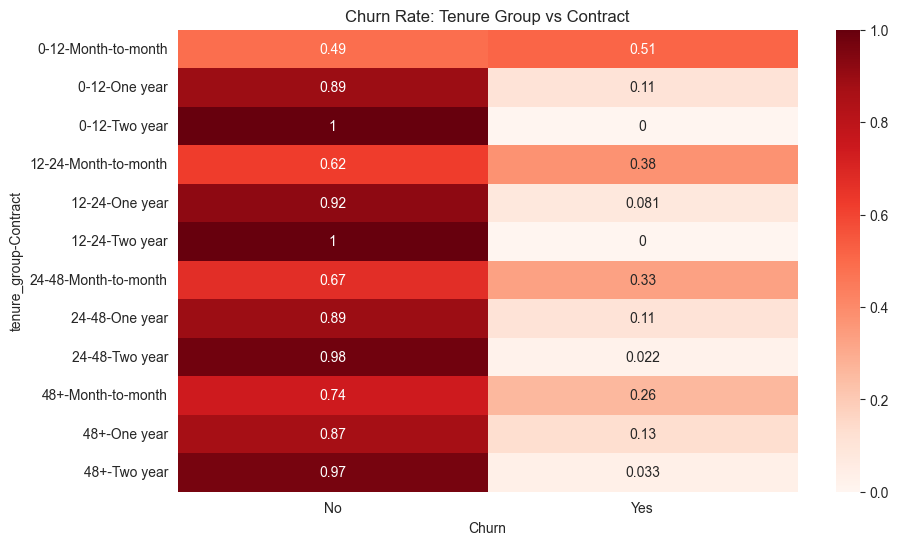

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(churn_table, annot=True, cmap="Reds")
plt.title("Churn Rate: Tenure Group vs Contract")
plt.show()

In [16]:
df["charge_bin"] = pd.cut(
    df["MonthlyCharges"],
    bins=5
)

charge_churn = pd.crosstab(
    df["charge_bin"],
    df["Churn"],
    normalize="index"
)

charge_churn

Churn,No,Yes
charge_bin,,
"(18.15, 38.35]",0.887269,0.112731
"(38.35, 58.45]",0.731805,0.268195
"(58.45, 78.55]",0.708303,0.291697
"(78.55, 98.65]",0.630340,0.369660
"(98.65, 118.75]",0.699427,0.300573


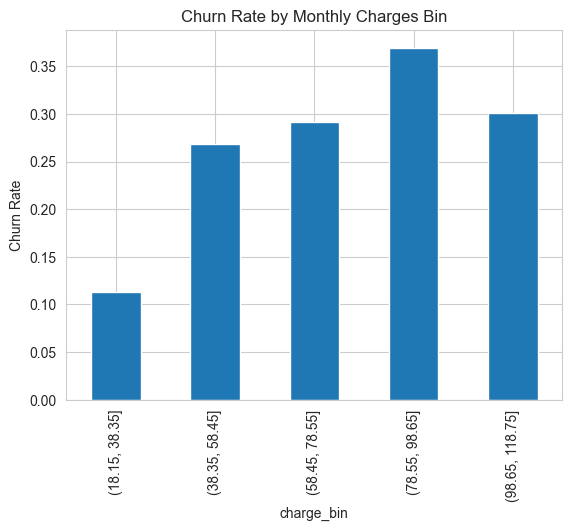

In [17]:
charge_churn["Yes"].plot(kind="bar")
plt.title("Churn Rate by Monthly Charges Bin")
plt.ylabel("Churn Rate")
plt.show()

In [18]:
fiber_df = df[df["InternetService"] == "Fiber optic"]

pd.crosstab(
    fiber_df["TechSupport"],
    fiber_df["Churn"],
    normalize="index"
)

Churn,No,Yes
TechSupport,,
No,0.507644,0.492356
Yes,0.773672,0.226328


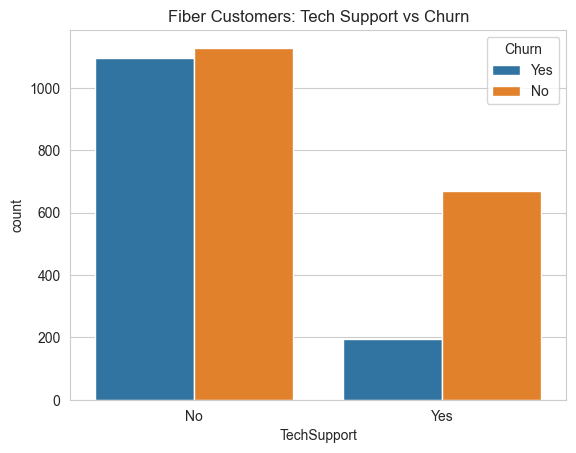

In [19]:
sns.countplot(x="TechSupport", hue="Churn", data=fiber_df)
plt.title("Fiber Customers: Tech Support vs Churn")
plt.show()

In [20]:
high_value_threshold = df["MonthlyCharges"].quantile(0.75)

high_value = df[df["MonthlyCharges"] > high_value_threshold]

pd.crosstab(
    high_value["Churn"],
    columns="count",
    normalize=True
)

col_0,count
Churn,
No,0.670857
Yes,0.329143


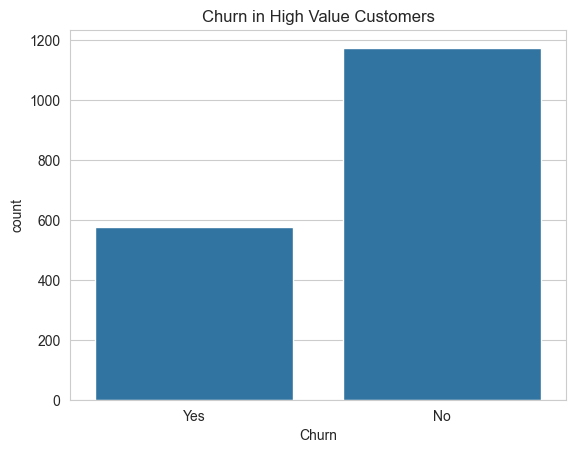

In [21]:
sns.countplot(x="Churn", data=high_value)
plt.title("Churn in High Value Customers")
plt.show()